# Fine-tune TrorYongASR for specific dataset

យើងនឹងផ្សាំ ត្រយ៉ងASR សម្រាប់ទិន្នន័យថ្មីដែលមិនបានថិតនៅក្នុងទិន្នន័យបុរេបង្ហាត់។
ទិន្នន័យដែលយើងនឹងប្រើប្រាស់ ជាទិន្នន័យក្នុងបរិបថចរាចរណ៍។

# lib install

In [ ]:
%%capture
! pip install jiwer evaluate

In [ ]:
!pip install tror-yong-asr

# Import

In [ ]:
from datasets import load_dataset

ds = load_dataset("KrorngAI/khmer-mpwt-speech-clean").with_format("numpy")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 2058
    })
})

In [ ]:
SEED = 3407

print(ds['train'][0])
ds = ds['train'].train_test_split(test_size=0.05, seed=SEED)
ds['validation'] = ds['test']
ds

{'audio': {'array': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
       -3.6848349e-05, -1.0379205e-05, -1.9985937e-05], dtype=float32), 'path': 'q-CatID02.mp3', 'sampling_rate': array(16000)}, 'transcription': np.str_('ផ្លាក សញ្ញា នេះ មាន ន័យ ដូចម្ដេច')}


DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 1955
    })
    test: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 103
    })
    validation: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 103
    })
})

In [ ]:
ds = ds.map(lambda x: {'transcription': x['transcription'].replace(" ", "")})

In [ ]:
import torch


class KmSpeechDataset(torch.utils.data.Dataset):
    def __init__(self, ds, processor) -> None:
        super().__init__()

        self.dataset = ds
        self.tokenizer = processor.tokenizer
        self.feature_extractor = processor.feature_extractor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, id):

        audio = self.dataset[id]['audio']
        mel = self.feature_extractor(audio['array'], sampling_rate=audio['sampling_rate'], return_tensors="pt").input_features[0]

        text = self.dataset[id]['transcription'].strip()
        token_ids = self.tokenizer(text) + [self.tokenizer.eot]

        return {
            "mel": mel,
            "token_ids": token_ids,
        }

In [ ]:
import numpy as np
import torch
from dataclasses import dataclass
n_text_ctx = 1024


@dataclass
class WhisperDataCollatorWithPadding:
    pad_id: int

    def __call__(self, features):
        mels, input_ids, target_ids, num_tokens = [], [], [], []
        for f in features:
            # mels.append(f["log_mel"])
            mels.append(f["mel"])
            target_ids.append(f["token_ids"][1:])
            input_ids.append(f["token_ids"][:-1])
            num_tokens.append(len(f["token_ids"])-1)

        mels = torch.concat([mel[None, :] for mel in mels])

        max_num_tok = max(num_tokens)
        max_num_tok = (max_num_tok + 63) // 64 * 64

        # truncate
        max_num_tok = min(n_text_ctx, max_num_tok)

        target_ids = [np.pad(tgt, (0, max_num_tok - n_tok), 'constant', constant_values=-100) for tgt, n_tok in zip(target_ids, num_tokens)]
        input_ids = [np.pad(inp, (0, max_num_tok - n_tok), 'constant', constant_values=self.pad_id) for inp, n_tok in zip(input_ids, num_tokens)]

        batch = {
            "mels": mels,
            "target_ids": torch.as_tensor(np.array(target_ids)).long(),
            "input_ids": torch.as_tensor(np.array(input_ids)).long()
        }

        return batch

# Confirm Dataloading

In [ ]:
from transformers import AutoProcessor

model_id = "KrorngAI/TrorYongASR-tiny"
processor = AutoProcessor.from_pretrained(model_id, language='km', task='transcribe', trust_remote_code=True)

In [ ]:
dataset = KmSpeechDataset(ds['train'], processor)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=2, collate_fn=WhisperDataCollatorWithPadding(processor.tokenizer.eot))

In [ ]:
for b in train_loader:
    print(b["target_ids"].shape)
    print(b["mels"].shape)
    print(b["input_ids"].shape)

    for token, dec in zip(b["target_ids"], b["input_ids"]):
        token[token == -100] = processor.tokenizer.eot
        text = processor.decode(token, skip_special_tokens=False)
        print(text)

        text = processor.decode(dec, skip_special_tokens=False)
        print(text)


    break

torch.Size([2, 64])
torch.Size([2, 80, 3000])
torch.Size([2, 64])
<|km|><|transcribe|>ហាមចតនៅផ្លូវបំបែករាងអ៊ីការិចនៅខាងមុខ</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>
<s><|km|><|transcribe|>ហាមចតនៅផ្លូវបំបែករាងអ៊ីការិចនៅខាងមុខ</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>
<|km|><|transcribe|>នៅពេលរថយន្តអ្នករអិលរេនៅលើផ្លូវស្ងួតតើអ្នកត្រូវធ្វើដូចម្ដេច</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>
<s><|km|><|transcribe|>នៅពេលរថយន្តអ្នករអិលរេនៅលើផ្លូវស្ងួតតើអ្នកត្រូវធ្វើដូចម្ដេច</s></s></s></s></s></s></s></s></s></s></s></s></s></s><

In [ ]:
from tror_yong_asr import TrorYongASRModel

wmodel = TrorYongASRModel.from_pretrained(model_id, trust_remote_code=True, verbose=False)


In [ ]:
with torch.no_grad():
    wmodel.to("cpu")
    input_ids = b["input_ids"]
    print(input_ids)
    target_ids = b["target_ids"]
    print(target_ids)

    mels = b["mels"]

    audio_features = wmodel.encode(mels)
    print(audio_features.shape)
    print(target_ids.shape, input_ids.shape, audio_features.shape)
    print()
    out = wmodel(mels, input_ids)#, target_ids)

tensor([[    1, 48000, 48002, 32648, 35639, 32027, 32414, 33604, 32727, 32451,
         32004, 32454, 32027, 33507,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2],
        [    1, 48000, 48002, 32566, 32801, 32045, 41332, 36850, 32506, 32414,
         34279, 32297, 32045, 32061, 32119, 37519,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
             2

In [ ]:
out = out.logits
print(out.shape)
print(out.view(-1, out.size(-1)).shape)
print(b["target_ids"].view(-1).shape)
tokens = torch.argmax(out, dim=2)

torch.Size([2, 64, 48064])
torch.Size([128, 48064])
torch.Size([128])


In [ ]:
for token in tokens:
    text = processor.decode(token, skip_special_tokens=True)
    print(text)

ហាន់ចុះនៅផ្លូវបំបែករាងអុីមអាចកខាងក្នុង។។ខាប់ខាប់។។។។។។។។។។។។។..។។.។។។។។។។.។។។។។។
នៅពេលរត់អ្នករអិលរលាយនៅលើផ្លូវត្នោតតែអ្នកត្រូវធ្វើដូចដោយត្រូវត្រូវ។។។។។។។។។។។។។.។។។។។រយៈពេល.។។។។។។។។។។។។។។ត្រូវត្រូវ។។។។។


In [ ]:
processor.tokenizer.sot_sequence

(1, 48000, 48002)

In [ ]:
wmodel.set_prefix(processor.tokenizer.sot_sequence)
with torch.no_grad():
    wmodel.to("cpu")
    mels = b["mels"]
    for mel in mels:
        out = wmodel.decode(mel, max_tokens=128, temperature=1.0, top_k=None)
        print(processor.decode(out[0], skip_special_tokens=True))

វីស៊ីនឱ្យនៅផ្លូវបំបែករាន Garcរីករាយៗកើតឡើង។
នៅពេលរើស abyរមែងរដូវalនារីនៅលើហើយអ្នកត្រូវធ្វើដូចដែក។


# Trainer

In [ ]:
from torch import nn
import torch.nn.functional as F

def estimate_loss(model):
    out = {}
    model.eval()
    eval_batches = 25
    with torch.inference_mode():
        for split, loader in zip(['train', 'val'], [train_loader, eval_loader]):
            losses = torch.zeros(eval_steps)
            k = 0
            for batch in loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                with ctx:
                    output = model(**batch)
                losses[k] = output.loss.item()

                k += 1
                if k >= eval_batches:
                    break
            out[split] = losses.mean()
    model.train()
    return out

In [ ]:
SEED = 168

In [ ]:
import torch
from contextlib import nullcontext


learning_rate = 2e-4
min_lr = 2e-5
max_steps = 500
warmup_steps = 25
eval_steps = 100
weight_decay = 0.1
adam_epsilon = 1e-9
batch_size = 4

gradient_accumulation_steps = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(SEED)

dataset = KmSpeechDataset(ds['train'], processor)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=WhisperDataCollatorWithPadding(pad_id=processor.tokenizer.eot))
dataset = KmSpeechDataset(ds['validation'], processor)
eval_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=WhisperDataCollatorWithPadding(pad_id=processor.tokenizer.eot))

In [ ]:
# only decoder training
for p in wmodel.encoder.parameters():
    p.requires_grad = False
total_params = sum([p.numel() for p in wmodel.parameters()]) / 1e6
num_params = sum([p.numel() for p in wmodel.parameters() if p.requires_grad]) / 1e6
print(num_params, '/', total_params)

21.266308 / 28.898692


In [ ]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(wmodel.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=weight_decay, eps=adam_epsilon)

scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay = CosineAnnealingLR(optimizer, T_max = max_steps - warmup_steps, eta_min=min_lr)
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps])

scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

In [ ]:
import torch.nn.functional as F
from tqdm.notebook import tqdm
from safetensors.torch import save_model

best_val_loss = float('inf')
best_model_params_path = 'model.safetensors'
train_loss_list, valid_loss_list = [], []

wmodel = wmodel.to(device)

it = 0
with tqdm(total=max_steps) as pbar:
    while it < max_steps:
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with ctx:
                output = wmodel(**batch)
                loss = output.loss
                loss = loss / gradient_accumulation_steps
                scaler.scale(loss).backward()

            if ((it + 1) % gradient_accumulation_steps == 0) or (it + 1 == max_steps):
                torch.nn.utils.clip_grad_norm_(wmodel.parameters(), max_norm=0.5)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            if (it+1) % eval_steps == 0:
                losses = estimate_loss(wmodel)
                print(f"Iterations {it+1}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
                print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
                train_loss_list += [losses['train']]
                valid_loss_list += [losses['val']]

                if losses['val'] < best_val_loss:
                    best_val_loss = losses['val']
                    save_model(wmodel, best_model_params_path)

            it += 1
            pbar.update(1) # Update the progress bar by 1 unit
            if it >= max_steps:
                break

  0%|          | 0/500 [00:00<?, ?it/s]

Iterations 100: train loss 0.5131, val loss 0.4336
The current learning rate: 0.00019
Iterations 200: train loss 0.4180, val loss 0.3573
The current learning rate: 0.00015
Iterations 300: train loss 0.3611, val loss 0.3163
The current learning rate: 0.00009
Iterations 400: train loss 0.3362, val loss 0.2993
The current learning rate: 0.00004
Iterations 500: train loss 0.3250, val loss 0.2906
The current learning rate: 0.00002


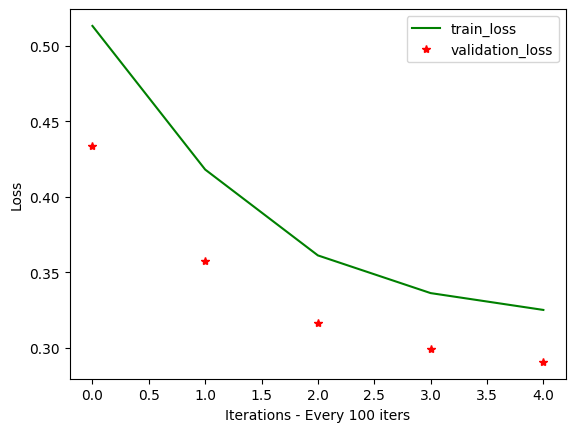

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in valid_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r*', label='validation_loss')
plt.xlabel(f"Iterations - Every {eval_steps} iters")
plt.ylabel("Loss")
plt.legend()
plt.show()



# load weight and inference

In [ ]:
!pip install khmercut

In [ ]:
from khmercut import tokenize

def separate_words(text: str):
    words = tokenize(text)
    return ' '.join(words)

In [ ]:
from tqdm import tqdm
from tror_yong_asr import TrorYongASRModel
from safetensors.torch import load_model


load_model(wmodel, best_model_params_path)
wmodel.eval()
wmodel.to(device)

dataset = KmSpeechDataset(ds['test'], processor)

refs = []
pred = []
i = 0
with torch.inference_mode():
    for sample in tqdm(dataset):
        mel = sample["mel"].to(device)

        out = wmodel.decode(mel, 512, temperature=0.0, top_k=25, seed=168)
        text = processor.decode(out[0].tolist(), skip_special_tokens=True)
        pred.append(separate_words(text))

        label = torch.tensor(sample["token_ids"]).long().to(device)
        text = processor.decode(label, skip_special_tokens=True)
        refs.append(separate_words(text))

100%|██████████| 103/103 [00:20<00:00,  4.99it/s]


In [ ]:
import evaluate


cer_metrics = evaluate.load("cer")
cer_metrics.compute(references=refs, predictions=pred)

0.24121113594797805

In [ ]:
wer_metrics = evaluate.load("wer")
wer_metrics.compute(references=refs, predictions=pred)

0.360427807486631

In [ ]:
for k, v in zip(refs, pred):
    print("-"*10)
    print(' ref:', k)
    print('pred:', v)

----------
 ref: ត្រូវ ឈប់ ឬ ចត ខាងស្ដាំ ដៃ តាម ទិស ចរាចរណ៍ របស់ ខ្លួន
pred: ត្រូវ ឈប់ ឬ ឈប់ ឬ ចុះ តាម ទិស ចរាចរណ៍ របស់ ខ្លួន
----------
 ref: ហាម ចូល ចំពោះ រថយន្ត ប្រភេទ ដឹក ទំនិញ ធុន ធំ មាន សណ្ដោង រ៉ឺម៉ក
pred: ហាម ចូល ចំពោះ រថយន្ត ប្រភេទ ដឹក ទំនិញ ធន់ មាន ចន្លោះ
----------
 ref: លេខ បី ទៅ មុន បន្ទាប់មក លេខ ពីរ និង លេខ មួយ
pred: លេខ បី ទៅ មុន បន្ទាប់មក លេខ ពីរ និង លេខ មួយ
----------
 ref: យ៉ាងតិច ដប់ ម៉ែត្រ
pred: យ៉ាងតិច ដប់ ម៉ែត្រ
----------
 ref: នៅក្នុង ទីក្រុង ឬ ទីប្រជុំជន រថយន្ត ធុន តូច ត្រូវបាន កម្រិត ល្បឿន អតិបរមា ប៉ុន្មាន គីឡូម៉ែត្រ ក្នុង មួយ ម៉ោង
pred: នៅក្នុង ទីក្រុង ឬ ទីប្រជុំជន រថយន្ត រថយន្ត រថយន្ត ធន់ តូច ត្រូវ វែង កម្រិត ល្បឿន អាទិភាព លេខ ម៉ែត្រ ក្នុង មួយ ម៉ោង
----------
 ref: ភាព លេច ជ្រាប ខ្យល់
pred: ភាព លេខរៀប ខ្យល់
----------
 ref: តម្រូវ ឱ្យ យានជំនិះ គ្រប់ ប្រភេទ ឈប់ ឬ ចត នៅ ខាងឆ្វេង ដៃ
pred: តម្រូវ ឱ្យ យាន ទំនេរ គ្រប់ ប្រភេទ ឈប់ ឬ ឈប់ ឬ ឈប់ ឬ ឈប់ ឬ ឈប់ ដៃ
----------
 ref: ប្រកាន់ ឆ្វេង
pred: ប្រចាំ ឆ្វេង
----------
 ref: ពាក់ មួក សុវត្ថិភាព ទាំង អ្នកបើកបរ និង អ្នក 